In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter
import gdown
import os

In [2]:
def read_img(url):
    file_id = url.split("/d/")[1].split("/")[0]
    download_url = f'https://drive.google.com/uc?id={file_id}'

    gdown.download(download_url,"img.jpg", quiet=False)

    return cv2.imread("img.jpg",cv2.IMREAD_GRAYSCALE)

In [3]:
def img_details(name,img,shape = None , i = None , cmap=None,show = 1):
    if shape and i is not None:
        plt.subplot(shape[0],shape[1],i)
        show = None
    if cmap is None:
       plt.imshow(img)
    else:
       plt.imshow(img,cmap=cmap)
    plt.title(f'{name}{img.shape}')

    if show is not None:
        plt.show()

    plt.tight_layout()

# **READ THE IMAGE**

In [4]:
img1 = read_img(r"https://drive.google.com/file/d/1IR-TdzKfzvEsWIcWbFjEewGkiGYe_WOi/view?usp=drive_link")
img2 = read_img(r"https://drive.google.com/file/d/1aRkiHJ2Q7T9TnowHchLB1R9lj4BFrQCK/view?usp=drive_link")

Downloading...
From: https://drive.google.com/uc?id=1IR-TdzKfzvEsWIcWbFjEewGkiGYe_WOi
To: C:\Users\sanka\PYTHON\COMPUTER VISION\img.jpg
100%|████████████████████████████████████████████████████████████████████████████████| 245k/245k [00:00<00:00, 684kB/s]
Downloading...
From: https://drive.google.com/uc?id=1aRkiHJ2Q7T9TnowHchLB1R9lj4BFrQCK
To: C:\Users\sanka\PYTHON\COMPUTER VISION\img.jpg
100%|██████████████████████████████████████████████████████████████████████████████| 38.8k/38.8k [00:00<00:00, 140kB/s]


# **CANNY**

In [7]:
def manual_canny(img, low_threshold, high_threshold):
    blurred = cv2.GaussianBlur(img, (5, 5), 1.4)

    gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(gx**2 + gy**2)
    angle = np.arctan2(gy, gx) * (180 / np.pi) % 180

    magnitude = non_max_suppression(magnitude, angle)
    edges = threshold_hysteresis(magnitude, low_threshold, high_threshold)

    return edges

In [8]:
def non_max_suppression(magnitude, angle):
    h, w = magnitude.shape
    suppressed = np.zeros((h, w), dtype=np.float32)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            direction = angle[i, j]

            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                neighbors = [magnitude[i, j - 1], magnitude[i, j + 1]]
            elif 22.5 <= direction < 67.5:
                neighbors = [magnitude[i - 1, j + 1], magnitude[i + 1, j - 1]]
            elif 67.5 <= direction < 112.5:
                neighbors = [magnitude[i - 1, j], magnitude[i + 1, j]]
            else:
                neighbors = [magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]]

            if magnitude[i, j] >= max(neighbors):
                suppressed[i, j] = magnitude[i, j]

    return suppressed

In [9]:
def threshold_hysteresis(magnitude, low, high):
    strong = 255
    weak = 50

    strong_i, strong_j = np.where(magnitude >= high)
    weak_i, weak_j = np.where((magnitude >= low) & (magnitude < high))

    edges = np.zeros_like(magnitude, dtype=np.uint8)
    edges[strong_i, strong_j] = strong
    edges[weak_i, weak_j] = weak

    return edges

In [15]:
def print_manual_canny(isManual = True):

    if isManual:
        canny = manual_canny
    else:
        canny = cv2.Canny
        
    s = (1, 2)
    plt.figure(figsize=(9, 9))

    edges1 = canny(img1, 100, 150)
    edges2 = canny(img2, 100, 150)

    img_details('Lenna Canny', edges1, s, 1, cmap='gray')
    img_details('Cameraman Canny', edges2, s, 2, cmap='gray')

    plt.tight_layout()
    plt.show()

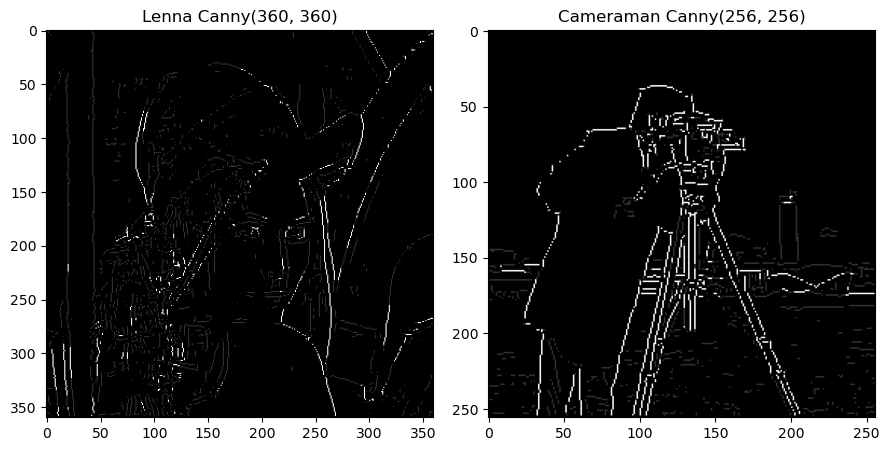

In [11]:
print_manual_canny()

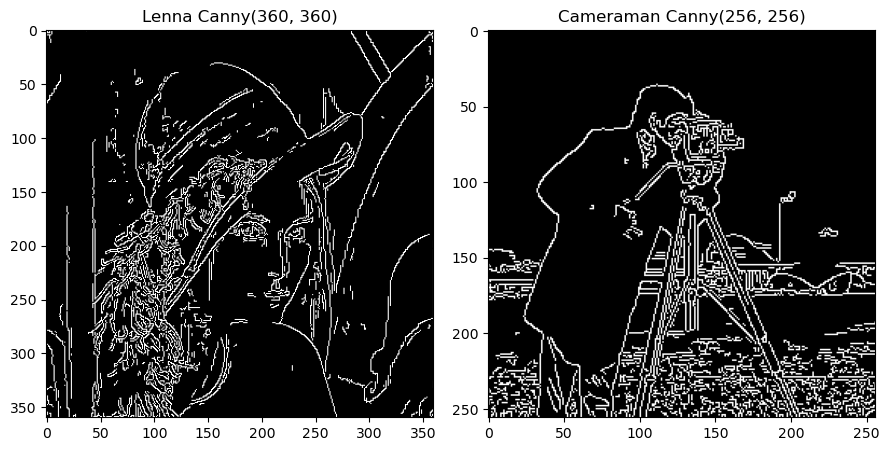

In [16]:
print_manual_canny(isManual = False)

# **ROBERTS**

In [14]:
def roberts_filter(img):
    kx = np.array([[1, 0], [0, -1]], dtype=np.float32)
    ky = np.array([[0, 1], [-1, 0]], dtype=np.float32)

    gx = cv2.filter2D(img.astype(np.float32), -1, kx)
    gy = cv2.filter2D(img.astype(np.float32), -1, ky)

    edges = np.sqrt(gx**2 + gy**2)
    edges = (edges / edges.max()) * 255
    return edges.astype(np.uint8)

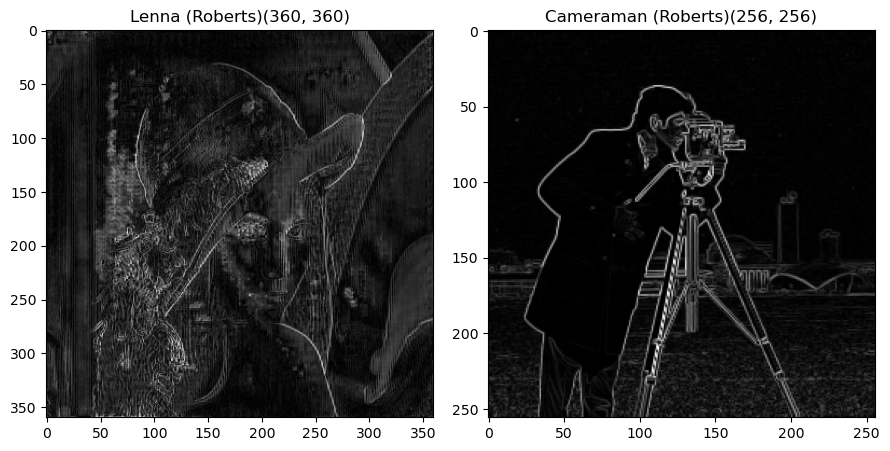

In [15]:
def print_roberts_filter():
    s = (1, 2)
    plt.figure(figsize=(9, 9))

    roberts1 = roberts_filter(img1)
    roberts2 = roberts_filter(img2)

    img_details('Lenna (Roberts)', roberts1, s, 1, cmap='gray')
    img_details('Cameraman (Roberts)', roberts2, s, 2, cmap='gray')

    plt.tight_layout()
    plt.show()

print_roberts_filter()

# **LOG DOG**

In [16]:
def log_filter(img, ksize=5, sigma=1.0):
    blurred = cv2.GaussianBlur(img, (ksize, ksize), sigma)
    return cv2.Laplacian(blurred, cv2.CV_64F).astype(np.uint8)

def dog_filter(img, sigma1=1.0, sigma2=2.0):
    blur1 = cv2.GaussianBlur(img, (0, 0), sigma1)
    blur2 = cv2.GaussianBlur(img, (0, 0), sigma2)
    return cv2.absdiff(blur1, blur2)

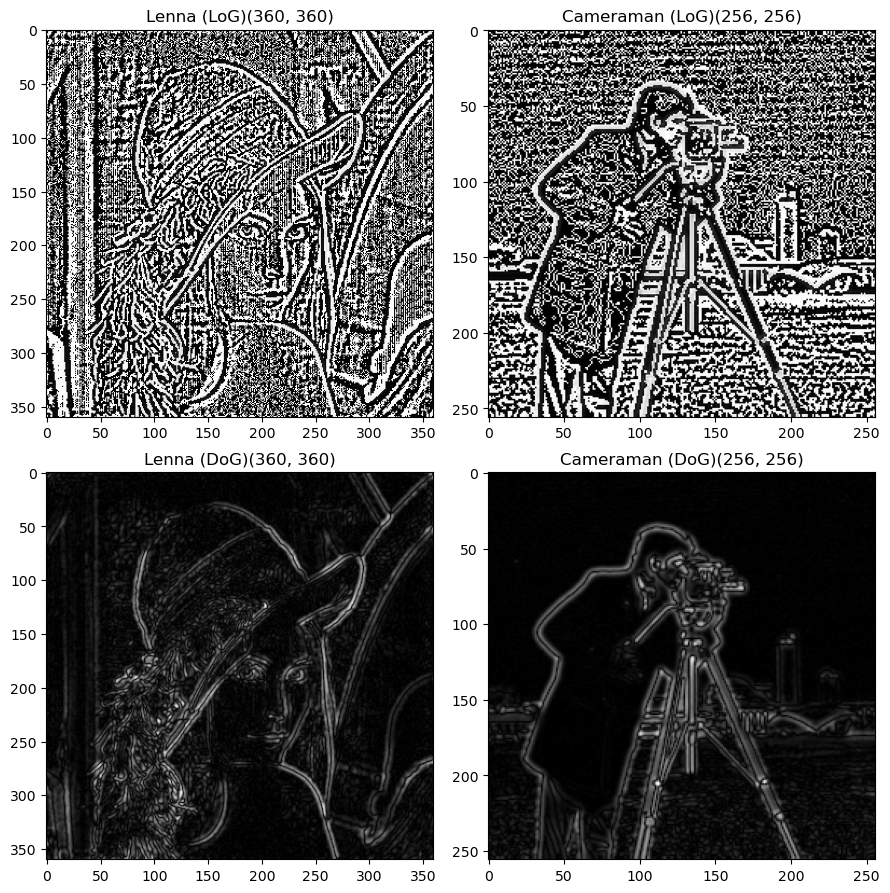

In [17]:
def print_log_dog():
    s = (2, 2)
    plt.figure(figsize=(9, 9))

    log1 = log_filter(img1)
    log2 = log_filter(img2)
    dog1 = dog_filter(img1)
    dog2 = dog_filter(img2)

    img_details('Lenna (LoG)', log1, s, 1, cmap='gray')
    img_details('Cameraman (LoG)', log2, s, 2, cmap='gray')
    img_details('Lenna (DoG)', dog1, s, 3, cmap='gray')
    img_details('Cameraman (DoG)', dog2, s, 4, cmap='gray')

    plt.tight_layout()
    plt.show()

print_log_dog()

In [18]:
def log_blob_detection(img):
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    log = cv2.Laplacian(blur, cv2.CV_64F)
    log = np.abs(log)  # Take absolute values
    log = (log / log.max() * 255).astype(np.uint8)  # Normalize and convert to uint8
    _, thresh = cv2.threshold(log, 50, 255, cv2.THRESH_BINARY)
    return thresh

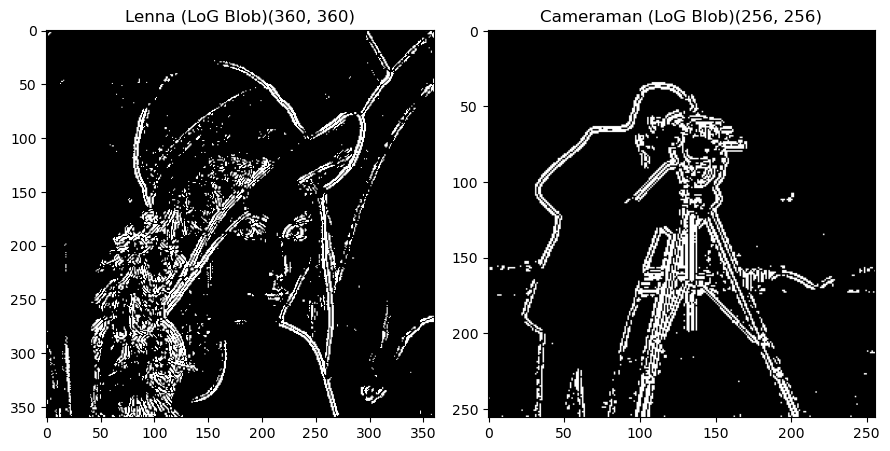

In [19]:
def print_log_blob():
    s = (2, 2)
    plt.figure(figsize=(9, 9))

    log1 = log_blob_detection(img1)
    log2 = log_blob_detection(img2)

    img_details('Lenna (LoG Blob)', log1, s, 1, cmap='gray')
    img_details('Cameraman (LoG Blob)', log2, s, 2, cmap='gray')

    plt.tight_layout()
    plt.show()

print_log_blob()
